In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
import matplotlib.pyplot as plt
from datetime import datetime

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cpu
CUDA available: False


In [3]:
# Load merged data 
df = pd.read_csv("nvda_prices_with_sentiment.csv", 
                 index_col="Date", 
                 parse_dates=True,
                 dayfirst=True)

print("Loaded shape:", df.shape)
print(df.tail(5))

# Add simple technical indicators
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_30'] = df['Close'].rolling(window=30).mean()
df['RSI'] = 100 - (100 / (1 + 
    (df['Close'].diff(1).clip(lower=0).rolling(14).mean() / 
     abs(df['Close'].diff(1).clip(upper=0).rolling(14).mean()))))

# Target variables
df['next_close'] = df['Close'].shift(-1)
df['direction'] = (df['next_close'] > df['Close']).astype(int)

# Drop rows with NaN (from rolling windows + shift)
df = df.dropna()

print("After prep shape:", df.shape)

Loaded shape: (2566, 7)
                 key_0       Close        High         Low        Open  \
Date                                                                     
2026-03-11  2026-03-11  186.029999  187.619995  184.449997  185.910004   
2026-03-12  2026-03-12  183.139999  184.940002  181.750000  184.050003   
2026-03-13  2026-03-13  180.250000  186.089996  179.940002  184.919998   
2026-03-16  2026-03-16  183.220001  188.880005  181.410004  182.970001   
2026-03-17  2026-03-17  181.929993  185.399994  181.680405  185.050003   

                 Volume  finbert_sentiment  
Date                                        
2026-03-11  145280400.0           0.000000  
2026-03-12  155762700.0           0.000000  
2026-03-13  160988400.0          -0.736447  
2026-03-16  217307400.0           0.000000  
2026-03-17  178520213.0          -0.109047  
After prep shape: (2535, 12)


In [4]:
# Features to use 
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'finbert_sentiment', 'SMA_10', 'SMA_30', 'RSI']

# Scale features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

# Target (regression & classification)
y_reg = df['next_close'].values
y_dir = df['direction'].values

# Create sequences
lookback = 60   # 60 past days → predict next day
X, y_reg_seq, y_dir_seq = [], [], []

for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i])
    y_reg_seq.append(y_reg[i])
    y_dir_seq.append(y_dir[i])

X = np.array(X)
y_reg_seq = np.array(y_reg_seq)
y_dir_seq = np.array(y_dir_seq)

print("X shape:", X.shape)           # (samples, lookback, features)
print("y_reg shape:", y_reg_seq.shape)

X shape: (2475, 60, 9)
y_reg shape: (2475,)


Train and Test Split

In [5]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_reg_train, y_reg_test = y_reg_seq[:train_size], y_reg_seq[train_size:]
y_dir_train, y_dir_test = y_dir_seq[:train_size], y_dir_seq[train_size:]

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 1980, Test samples: 495


In [6]:
class StockDataset(Dataset):
    def __init__(self, X, y_reg, y_dir):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32).unsqueeze(1)
        self.y_dir = torch.tensor(y_dir, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_reg[idx], self.y_dir[idx]

train_dataset = StockDataset(X_train, y_reg_train, y_dir_train)
test_dataset  = StockDataset(X_test,  y_reg_test,  y_dir_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

LSTM Model

In [7]:
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout)
        self.fc_reg   = nn.Linear(hidden_size, 1)         # next price
        self.fc_class = nn.Linear(hidden_size, 1)         # direction prob

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h = h_n[-1]                  # last layer hidden state
        reg_out   = self.fc_reg(h)
        class_out = torch.sigmoid(self.fc_class(h))
        return reg_out, class_out

# Instantiate
input_size = X.shape[2]   # number of features
model = StockLSTM(input_size=input_size)
print(model)

StockLSTM(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc_reg): Linear(in_features=64, out_features=1, bias=True)
  (fc_class): Linear(in_features=64, out_features=1, bias=True)
)


Training

Epoch 1/500, Loss: 321.124521
Epoch 2/500, Loss: 286.407288
Epoch 3/500, Loss: 273.260306
Epoch 4/500, Loss: 265.917857
Epoch 5/500, Loss: 261.836945
Epoch 6/500, Loss: 259.630167
Epoch 7/500, Loss: 258.503054
Epoch 8/500, Loss: 257.982714
Epoch 9/500, Loss: 257.797977
Epoch 10/500, Loss: 257.784649
Epoch 11/500, Loss: 257.857389
Epoch 12/500, Loss: 257.961446
Epoch 13/500, Loss: 258.071826
Epoch 14/500, Loss: 258.177366
Epoch 15/500, Loss: 258.268100
Epoch 16/500, Loss: 258.345971
Epoch 17/500, Loss: 258.411602
Epoch 18/500, Loss: 258.464636
Epoch 19/500, Loss: 258.507324
Epoch 20/500, Loss: 258.540942
Epoch 21/500, Loss: 258.568517
Epoch 22/500, Loss: 258.590593
Epoch 23/500, Loss: 258.607679
Epoch 24/500, Loss: 258.620922
Epoch 25/500, Loss: 258.631853
Epoch 26/500, Loss: 258.640837
Epoch 27/500, Loss: 258.646368
Epoch 28/500, Loss: 258.651934
Epoch 29/500, Loss: 258.656759
Epoch 30/500, Loss: 258.660515
Epoch 31/500, Loss: 258.662397
Epoch 32/500, Loss: 258.665331
Epoch 33/500, Los

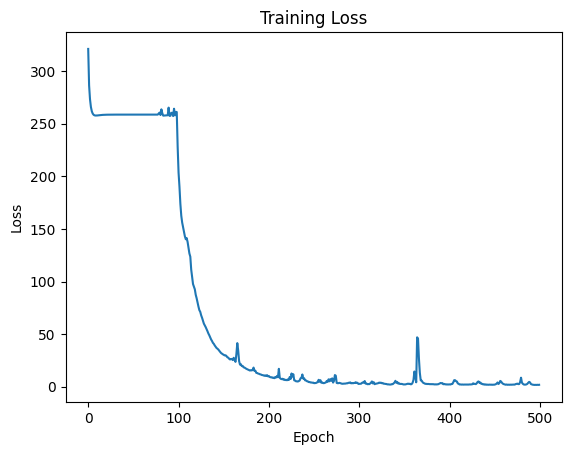

In [8]:
criterion_reg = nn.MSELoss()
criterion_class = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 500
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y_reg, batch_y_class in train_loader:
        batch_x, batch_y_reg, batch_y_class = batch_x.to(device), batch_y_reg.to(device), batch_y_class.to(device)
        
        optimizer.zero_grad()
        reg_out, class_out = model(batch_x)
        
        loss_reg = criterion_reg(reg_out, batch_y_reg)
        loss_class = criterion_class(class_out, batch_y_class)
        loss = loss_reg + loss_class
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

# Quick loss plot
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Evaluation on Test Set

In [9]:
model.eval()
reg_preds, class_preds = [], []

with torch.no_grad():
    for batch_x, _, _ in test_loader:
        batch_x = batch_x.to(device)
        reg_out, class_out = model(batch_x)
        reg_preds.extend(reg_out.cpu().numpy().flatten())
        class_preds.extend((class_out.cpu().numpy().flatten() > 0.5).astype(int))

# Inverse scale regression predictions (approximate)
# (for MAE in original scale — need to inverse-transform properly later)

mae = mean_absolute_error(y_reg_test, reg_preds)
rmse = np.sqrt(mean_squared_error(y_reg_test, reg_preds))
dir_acc = accuracy_score(y_dir_test, class_preds)

print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Directional Accuracy: {dir_acc:.2%}")

Test MAE: 59.9308
Test RMSE: 68.2520
Directional Accuracy: 53.13%
